Collisions of two dark solitons in 1d

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
L, N = 50.0, 1024
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
k = 2 * np.pi * fftfreq(N, d=dx)

dt = 0.001
kappa = 30.0
T_final = 5.0
steps_per_frame = 30
total_frames = int((T_final / dt) / steps_per_frame)

In [3]:
def gray_soliton(x, x0, nu, kappa):
    xi = 1.0 / np.sqrt(kappa)
    gamma = np.sqrt(1 - nu**2)
    return (1j * nu + gamma * np.tanh(gamma * (x - x0) / xi))

psi = (gray_soliton(x, -7, 0.7, kappa) * gray_soliton(x, 7, -0.7, kappa)).astype(complex)
psi_init = psi.copy()

In [4]:
times, densities, energies = [], [], []

def get_stats(p, k_vec, dx_val, kappa):
    dens = np.sum(np.abs(p)**2) * dx_val
    p_hat = fft(p)
    d_psi = ifft(1j * k_vec * p_hat)
    ener = np.sum(0.5 * np.abs(d_psi)**2 + 0.5 * kappa * np.abs(p)**4) * dx_val
    return dens, ener

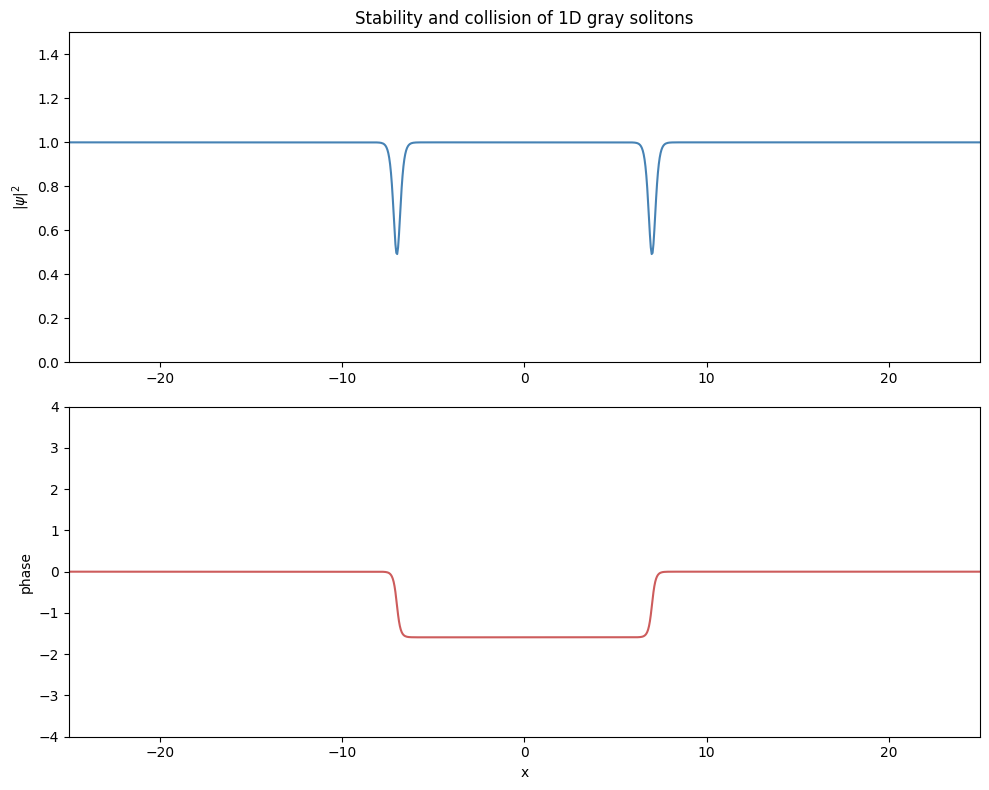

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
line_dens, = ax1.plot(x, np.abs(psi)**2, color='steelblue')
line_phase, = ax2.plot(x, np.angle(psi), color='indianred')

ax1.set_ylim(0, 1.5)
ax1.set_xlim(-L/2, L/2)
ax1.set_title("Stability and collision of 1D gray solitons")
ax1.set_ylabel(fr"$|\psi|^2$")

ax2.set_ylim(-4, 4)
ax2.set_xlim(-L/2, L/2)
ax2.set_ylabel("phase")
ax2.set_xlabel("x")

plt.tight_layout()

In [6]:
aux = 0
def update(frame):
    global psi, aux
    for _ in range(steps_per_frame):
        # TSSP
        psi *= np.exp(-0.5j * (kappa * (np.abs(psi)**2 - 1)) * dt)
        p_hat = fft(psi)
        p_hat *= np.exp(-0.5j * k**2 * dt)
        psi = ifft(p_hat)
        psi *= np.exp(-0.5j * (kappa * (np.abs(psi)**2 - 1)) * dt)
    
    aux += 1

    if aux % 10 == 0:
        d, e = get_stats(psi, k, dx, kappa)
        densities.append(d)
        energies.append(e)
        times.append(frame * dt * 8)

    line_dens.set_ydata(np.abs(psi)**2)
    line_phase.set_ydata(np.angle(psi))
    return line_dens, line_phase

ani = FuncAnimation(fig, update, frames=total_frames, blit=True)
ani.save("dark_solitons_1d/ds1d.html", writer='html')

plt.close()


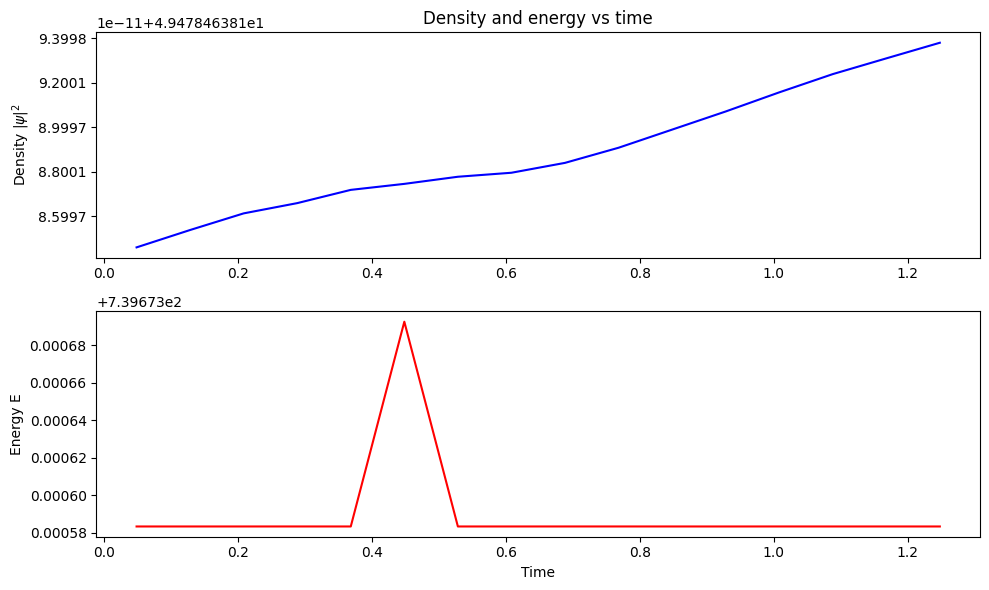

In [7]:
fig_stats, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.set_title("Density and energy vs time")
ax1.plot(times, densities, 'b'); ax1.set_ylabel(r"Density $|\psi|^2$")
ax2.plot(times, energies, 'r'); ax2.set_ylabel("Energy E")
ax2.set_xlabel("Time")
plt.tight_layout()
plt.savefig("dark_solitons_1d/te_ds1d.pdf")
plt.show()